In [5]:
import pandas as pd
import numpy as np

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import warnings


In [9]:
import warnings

warnings.simplefilter(
    action='ignore',
    category=FutureWarning
)

warnings.simplefilter(
    action='ignore',
    category=DeprecationWarning
)

In [10]:
url="https://raw.githubusercontent.com/alfonsodev12/analisisaseguradoras/refs/heads/main/archivos/data/Motor_Vehicle_Collisions_-_Crashes_20260530(in).csv"

In [13]:
df = pd.read_csv(url)

In [14]:


df.head()

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,01/02/2025,17:39,BRONX,10459.0,40.818798,-73.89212,"(40.818798, -73.89212)",BRUCKNER BLVD,BARRETTO ST,NaN,...,Unspecified,NaN,NaN,NaN,4783377,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
1,01/02/2025,06:50,QUEENS,11368.0,40.740757,-73.85311,"(40.740757, -73.85311)",NaN,NaN,55-20 VAN CLEEF ST,...,NaN,NaN,NaN,NaN,4783296,Sedan,NaN,NaN,NaN,NaN
2,01/02/2025,18:45,STATEN ISLAND,10304.0,40.593260,-74.11065,"(40.59326, -74.11065)",FOUR CORNERS RD,TODT HILL RD,NaN,...,Unspecified,NaN,NaN,NaN,4783776,Sedan,Taxi,NaN,NaN,NaN
3,01/02/2025,18:20,QUEENS,11375.0,40.721455,-73.84398,"(40.721455, -73.84398)",71 AVE,QUEENS BLVD,NaN,...,NaN,NaN,NaN,NaN,4783479,Sedan,NaN,NaN,NaN,NaN
4,01/02/2025,19:10,QUEENS,11354.0,40.764652,-73.82349,"(40.764652, -73.82349)",PARSONS BLVD,NORTHERN BLVD,NaN,...,Unspecified,NaN,NaN,NaN,4783622,Station Wagon/Sport Utility Vehicle,Sedan,NaN,NaN,NaN


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105380 entries, 0 to 105379
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CRASH DATE                     105380 non-null  object 
 1   CRASH TIME                     105380 non-null  object 
 2   BOROUGH                        83702 non-null   object 
 3   ZIP CODE                       83682 non-null   float64
 4   LATITUDE                       104260 non-null  float64
 5   LONGITUDE                      104260 non-null  float64
 6   LOCATION                       104260 non-null  object 
 7   ON STREET NAME                 72617 non-null   object 
 8   CROSS STREET NAME              61596 non-null   object 
 9   OFF STREET NAME                32762 non-null   object 
 10  NUMBER OF PERSONS INJURED      105380 non-null  int64  
 11  NUMBER OF PERSONS KILLED       105371 non-null  float64
 12  NUMBER OF PEDESTRIANS INJURED 

In [17]:
df.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME',
       'OFF STREET NAME', 'NUMBER OF PERSONS INJURED',
       'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'],
      dtype='object')

In [18]:
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'])

In [19]:
df['MES'] = df['CRASH DATE'].dt.month_name()

In [20]:
df['DIA_SEMANA'] = df['CRASH DATE'].dt.day_name()

In [21]:
def periodo(hora):

    hora = int(str(hora).split(':')[0])

    if hora < 6:
        return "Madrugada"

    elif hora < 12:
        return "Mañana"

    elif hora < 18:
        return "Tarde"

    else:
        return "Noche"

In [22]:
df['PERIODO'] = df['CRASH TIME'].apply(periodo)

In [23]:
def gravedad(fila):

    if fila['NUMBER OF PERSONS KILLED'] > 0:
        return "Fatal"

    elif fila['NUMBER OF PERSONS INJURED'] > 0:
        return "Con_Lesionados"

    else:
        return "Sin_Lesionados"

In [24]:
df['GRAVEDAD'] = df.apply(
    gravedad,
    axis=1
)

In [25]:
df_apriori = df[
[
    'BOROUGH',
    'PERIODO',
    'CONTRIBUTING FACTOR VEHICLE 1',
    'VEHICLE TYPE CODE 1',
    'GRAVEDAD'
]
]

In [26]:
df_apriori = df_apriori.fillna('DESCONOCIDO')

In [27]:
transacciones = []

for _, fila in df_apriori.iterrows():

    transaccion = [
        str(fila['BOROUGH']),
        str(fila['PERIODO']),
        str(fila['CONTRIBUTING FACTOR VEHICLE 1']),
        str(fila['VEHICLE TYPE CODE 1']),
        str(fila['GRAVEDAD'])
    ]

    transacciones.append(transaccion)

In [28]:
te = TransactionEncoder()

te_array = te.fit(
    transacciones
).transform(
    transacciones
)

df_trans = pd.DataFrame(
    te_array,
    columns=te.columns_
)

df_trans.head()

,18 wheeler,2 dr sedan,3-Door,4 dr sedan,4dsd,52,A,ACCESS A R,ACCESS RID,ACCESS-A-R,...,trac,tractor tr,trk-m1,truck,two wheel,vAN,van,van truck,volks,yellow bus
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [29]:
frequent_itemsets = apriori(
    df_trans,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.120782,(BRONX)
1,0.282179,(BROOKLYN)
2,0.030888,(Backing Unsafely)
3,0.020706,(Bus)
4,0.426210,(Con_Lesionados)


In [30]:
reglas = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

In [31]:
reglas = reglas.sort_values(
    by='lift',
    ascending=False
)

In [32]:
reglas[
[
'antecedents',
'consequents',
'support',
'confidence',
'lift'
]
].head(20)

,antecedents,consequents,support,confidence,lift
29,(Following Too Closely),(DESCONOCIDO),0.022585,0.421090,1.887793
15,(Failure to Yield Right-of-Way),(Con_Lesionados),0.049136,0.745787,1.749812
57,(Passing Too Closely),(Sin_Lesionados),0.027510,0.842243,1.474198
304,"(Sedan, Sin_Lesionados, BROOKLYN)",(Unspecified),0.027633,0.362144,1.388544
311,"(Sedan, Sin_Lesionados, Mañana)",(Unspecified),0.024236,0.360327,1.381578
12,(Backing Unsafely),(Sin_Lesionados),0.023942,0.775115,1.356703
86,"(Sin_Lesionados, BRONX)",(Unspecified),0.023894,0.346928,1.330200
314,"(Mañana, Unspecified)","(Sedan, Sin_Lesionados)",0.024236,0.354378,1.297940
126,"(Sin_Lesionados, BROOKLYN)",(Unspecified),0.054052,0.337841,1.295361
323,"(Sedan, Sin_Lesionados, Tarde)",(Unspecified),0.030385,0.335042,1.284630


In [35]:
total_accidentes = len(df)

print(total_accidentes)

105380


In [36]:
df['NUMBER OF PERSONS INJURED'].sum()

np.int64(59976)

In [37]:
df['NUMBER OF PERSONS KILLED'].sum()

np.float64(274.0)

In [38]:
(
    df['NUMBER OF PERSONS KILLED'].sum()
    /
    len(df)
)*100

np.float64(0.2600113873600303)

In [39]:
df['NUMBER OF PERSONS INJURED'].mean()

np.float64(0.5691402543177073)

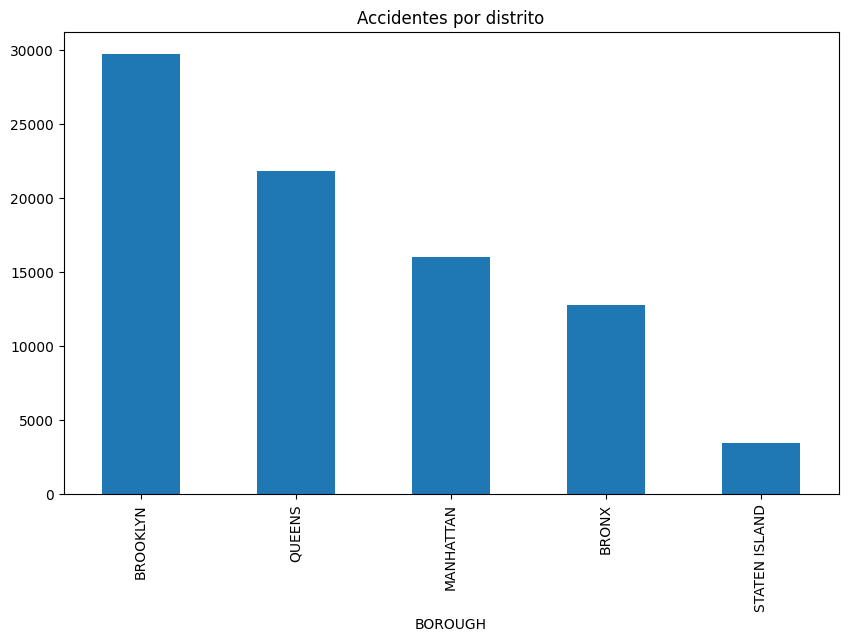

In [41]:
import matplotlib.pyplot as plt

accidentes = df['BOROUGH'].value_counts()

plt.figure(figsize=(10,6))

accidentes.plot(kind='bar')

plt.title('Accidentes por distrito')

plt.show()

<Axes: xlabel='CONTRIBUTING FACTOR VEHICLE 1'>

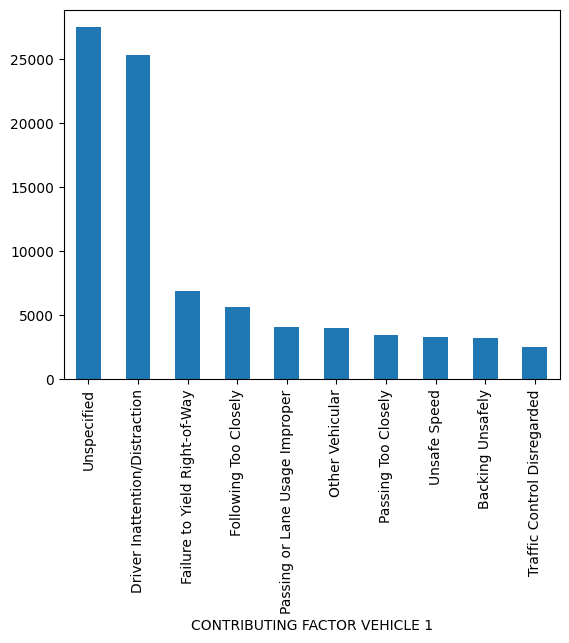

In [42]:
causas = df[
    'CONTRIBUTING FACTOR VEHICLE 1'
].value_counts().head(10)

causas.plot(kind='bar')

<Axes: xlabel='VEHICLE TYPE CODE 1'>

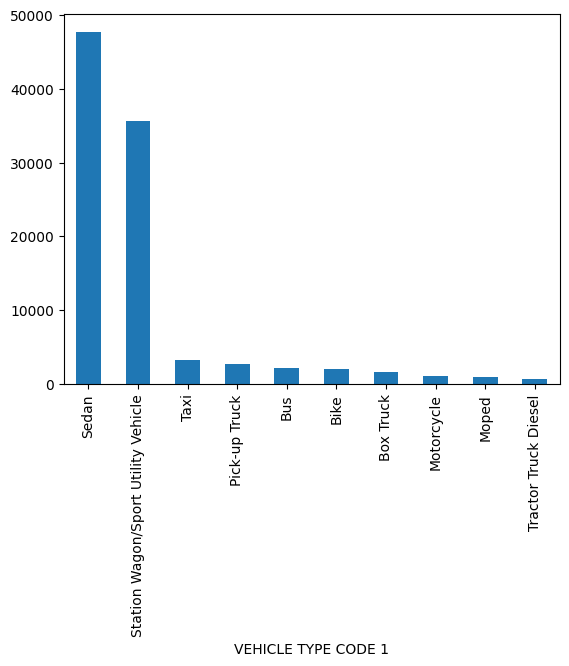

In [43]:
vehiculos = df[
    'VEHICLE TYPE CODE 1'
].value_counts().head(10)

vehiculos.plot(kind='bar')

<Axes: xlabel='MES'>

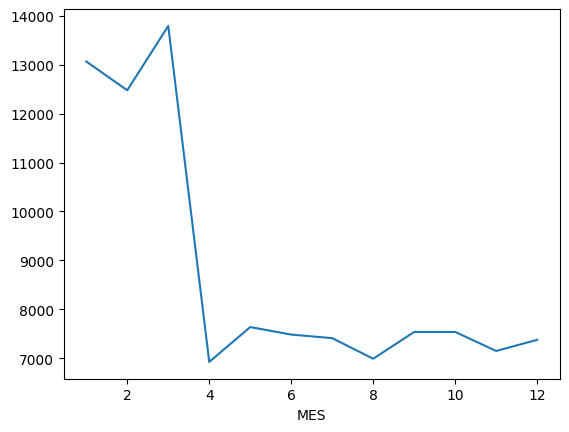

In [44]:
df['CRASH DATE'] = pd.to_datetime(
    df['CRASH DATE']
)

df['MES'] = df['CRASH DATE'].dt.month

df.groupby('MES').size().plot()

In [45]:
df['NUMBER OF PERSONS INJURED'].mean()

np.float64(0.5691402543177073)